In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


import warnings
warnings.filterwarnings('ignore')

1]Write a Python program that loads a dataset, splits it into training and testing sets, applies Logistic 
Regression, and prints the model accuracy

In [3]:
from sklearn.datasets import load_iris 

# Load the dataset (Example: Iris dataset)
data = load_iris()

# Convert the data into a DataFrame
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['target'] = data.target

# Split the dataset into features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=200)

# Train the model on the training data
model.fit(X_train, y_train)

# Predict on the testing data
y_pred = model.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 100.00%


2]Write a Python program to apply L1 regularization (Lasso) on a dataset using LogisticRegression(penalty='l1') 
and print the model accuracy

In [4]:
# Initialize the Logistic Regression model with L1 regularization (Lasso)
model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=200)

# Train the model on the training data
model.fit(X_train, y_train)

# Predict on the testing data
y_pred = model.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy with L1 Regularization (Lasso): {accuracy * 100:.2f}%")

Model Accuracy with L1 Regularization (Lasso): 100.00%


3] Write a Python program to train Logistic Regression with L2 regularization (Ridge) using 
LogisticRegression(penalty='l2'). Print model accuracy and coefficients

In [5]:
# Initialize the Logistic Regression model with L2 regularization (Ridge)
model = LogisticRegression(penalty='l2', solver='liblinear', max_iter=200)

# Train the model on the training data
model.fit(X_train, y_train)

# Predict on the testing data
y_pred = model.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy with L2 Regularization (Ridge): {accuracy * 100:.2f}%")

# Print the model coefficients
print("Model Coefficients (L2 Regularization):")
print(model.coef_)

Model Accuracy with L2 Regularization (Ridge): 100.00%
Model Coefficients (L2 Regularization):
[[ 0.3711229   1.409712   -2.15210117 -0.95474179]
 [ 0.49400451 -1.58897112  0.43717015 -1.11187838]
 [-1.55895271 -1.58893375  2.39874554  2.15556209]]


4] Write a Python program to train Logistic Regression with Elastic Net Regularization (penalty='elasticnet')

In [6]:
# Initialize the Logistic Regression model with Elastic Net regularization
# Set l1_ratio to control the balance between L1 and L2 regularization (e.g., 0.5 for equal mix)
model = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=200)

# Train the model on the training data
model.fit(X_train, y_train)

# Predict on the testing data
y_pred = model.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy with Elastic Net Regularization: {accuracy * 100:.2f}%")

# Print the model coefficients
print("Model Coefficients (Elastic Net Regularization):")
print(model.coef_)

Model Accuracy with Elastic Net Regularization: 100.00%
Model Coefficients (Elastic Net Regularization):
[[ 0.39058839  1.76993991 -2.42275447 -0.70944084]
 [ 0.07743454  0.          0.         -0.58271587]
 [-1.25872768 -1.53166335  2.59462936  2.08083957]]


5] Write a Python program to train a Logistic Regression model for multiclass classification using 
multi_class='ovr'

In [7]:
# Initialize the Logistic Regression model for multiclass classification (One-vs-Rest)
model = LogisticRegression(multi_class='ovr', solver='liblinear', max_iter=200)

# Train the model on the training data
model.fit(X_train, y_train)

# Predict on the testing data
y_pred = model.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy with One-vs-Rest Strategy: {accuracy * 100:.2f}%")

# Print the model coefficients
print("Model Coefficients (One-vs-Rest Strategy):")
print(model.coef_)

Model Accuracy with One-vs-Rest Strategy: 100.00%
Model Coefficients (One-vs-Rest Strategy):
[[ 0.3711229   1.409712   -2.15210117 -0.95474179]
 [ 0.49400451 -1.58897112  0.43717015 -1.11187838]
 [-1.55895271 -1.58893375  2.39874554  2.15556209]]


6] Write a Python program to apply GridSearchCV to tune the hyperparameters (C and penalty) of Logistic 
Regression. Print the best parameters and accuracy

In [8]:
# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=200)

# Define the hyperparameters grid to tune
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization strength (inverse)
    'penalty': ['l2', 'l1', 'elasticnet'],  # Type of regularization
}

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

# Perform grid search on the training data
grid_search.fit(X_train, y_train)

# Print the best parameters found by GridSearchCV
print(f"Best Hyperparameters: {grid_search.best_params_}")

# Predict on the testing data using the best model
y_pred = grid_search.predict(X_test)

# Calculate and print the accuracy of the best model
accuracy = accuracy_score(y_test, y_pred)
print(f"Best Model Accuracy: {accuracy * 100:.2f}%")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Hyperparameters: {'C': 1, 'penalty': 'l2'}
Best Model Accuracy: 100.00%


7] Write a Python program to evaluate Logistic Regression using Stratified K-Fold Cross-Validation. Print the 
average accuracy

In [9]:
from sklearn.model_selection import StratifiedKFold

# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=200)

# Set up the Stratified K-Fold cross-validation (5 folds)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# List to store accuracy for each fold
accuracies = []

# Perform Stratified K-Fold Cross-Validation
for train_index, test_index in kf.split(X, y):
    # Split data into training and testing sets for this fold
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Train the model on the training data
    model.fit(X_train, y_train)
    
    # Make predictions on the testing data
    y_pred = model.predict(X_test)
    
    # Calculate the accuracy for this fold
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# Calculate and print the average accuracy across all folds
average_accuracy = sum(accuracies) / len(accuracies)
print(f"Average Accuracy from Stratified K-Fold Cross-Validation: {average_accuracy * 100:.2f}%")

Average Accuracy from Stratified K-Fold Cross-Validation: 96.67%


8] Write a Python program to load a dataset from a CSV file, apply Logistic Regression, and evaluate its 
accuracy

In [10]:
# Load the dataset from a CSV file
# Replace 'your_dataset.csv' with the path to your actual CSV file
df = pd.read_csv(r"C:\Users\sesur\Downloads\logistic_regression.csv")

# Display the first few rows of the dataset to understand its structure
print(df.head())

# Assuming the target variable is the last column; adjust as necessary
# Features (X) will be all columns except the target column
X = df.iloc[:, :-1]  # Features (all columns except the last one)
y = df.iloc[:, -1]   # Target (the last column)

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=200)

# Train the model on the training data
model.fit(X_train, y_train)

# Predict on the testing data
y_pred = model.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

    Studied     Slept  Passed
0  4.855064  9.639962       1
1  8.625440  0.058927       0
2  3.828192  0.723199       0
3  7.150955  3.899420       1
4  6.477900  8.198181       1
Model Accuracy: 95.00%


9]Write a Python program to apply RandomizedSearchCV for tuning hyperparameters (C, penalty, solver) in 
Logistic Regression. Print the best parameters and accuracy

In [11]:
from sklearn.model_selection import  RandomizedSearchCV
import numpy as np

# Load the dataset (Example: Iris dataset)
data = load_iris()

# Convert the data into a DataFrame
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['target'] = data.target

# Split the dataset into features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=200)

# Define the hyperparameter space to search over
param_distributions = {
    'C': np.logspace(-4, 4, 20),  # Regularization strength (log scale)
    'penalty': ['l1', 'l2', 'elasticnet'],  # Regularization types
    'solver': ['liblinear', 'saga']  # Solvers that support L1, L2, and ElasticNet
}

# Set up the RandomizedSearchCV with 5-fold cross-validation
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_distributions, 
                                   n_iter=10, cv=5, random_state=42, n_jobs=-1, verbose=1)

# Perform RandomizedSearchCV to tune the hyperparameters
random_search.fit(X_train, y_train)

# Print the best hyperparameters found by RandomizedSearchCV
print(f"Best Hyperparameters: {random_search.best_params_}")

# Predict on the testing data using the best model
y_pred = random_search.predict(X_test)

# Calculate and print the accuracy of the best model
accuracy = accuracy_score(y_test, y_pred)
print(f"Best Model Accuracy: {accuracy * 100:.2f}%")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Hyperparameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.615848211066026}
Best Model Accuracy: 100.00%


10]Write a Python program to implement One-vs-One (OvO) Multiclass Logistic Regression and print accuracy

In [12]:
from sklearn.multiclass import OneVsOneClassifier

# Initialize the Logistic Regression model
logreg = LogisticRegression(max_iter=200)

# Initialize the One-vs-One classifier
ovo_classifier = OneVsOneClassifier(logreg)

# Train the model on the training data
ovo_classifier.fit(X_train, y_train)

# Predict on the testing data
y_pred = ovo_classifier.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"One-vs-One Multiclass Logistic Regression Accuracy: {accuracy * 100:.2f}%")


One-vs-One Multiclass Logistic Regression Accuracy: 100.00%


11] Write a Python program to train a Logistic Regression model and visualize the confusion matrix for binary 
classification

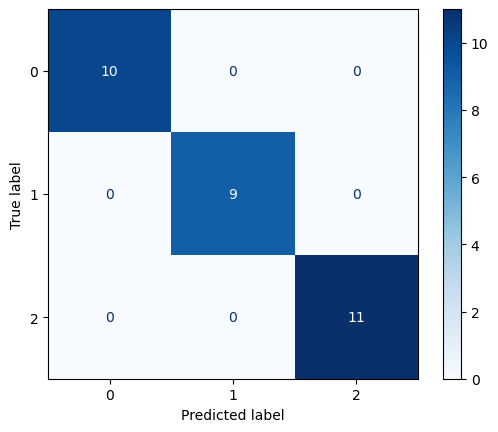

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Initialize the Logistic Regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')

# Show the plot
plt.show()

12]Write a Python program to train a Logistic Regression model and evaluate its performance using Precision, 
Recall, and F1-Score

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.datasets import make_classification

# Generate a synthetic binary classification dataset
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Logistic Regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using Precision, Recall, and F1-Score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display the results
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Precision: 0.8767
Recall: 0.8258
F1-Score: 0.8505


13] Write a Python program to train a Logistic Regression model on imbalanced data and apply class weights to 
improve model performance

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       145
           1       0.88      0.83      0.85       155

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300



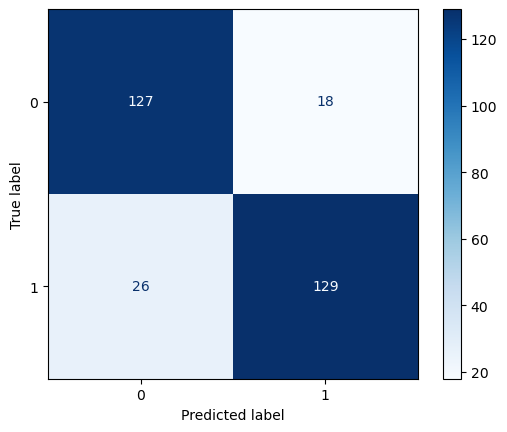

In [22]:
# Initialize the Logistic Regression model with class weight 'balanced'
model = LogisticRegression(class_weight='balanced')

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')

# Show the plot
plt.show()

14] Write a Python program to train Logistic Regression on the Titanic dataset, handle missing values, and 
evaluate performance

In [34]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer


# Load the Titanic dataset (Make sure the Titanic dataset is in CSV format)

titanic_df = pd.read_csv(r"C:\Users\sesur\Downloads\titanic_train.csv")

In [35]:
titanic_df.head(5)

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
# 1. Handle missing values
# Impute missing numerical data with the median of each column
print(titanic_df.isnull().sum())
numerical_cols = titanic_df.select_dtypes(include=['float64', 'int64']).columns
imputer = SimpleImputer(strategy='median')
titanic_df[numerical_cols] = imputer.fit_transform(titanic_df[numerical_cols])

Unnamed: 0       0
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [38]:
titanic_df.isnull().sum()

Unnamed: 0     0
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [37]:
# Impute missing categorical data with the most frequent value (mode)
categorical_cols = titanic_df.select_dtypes(include=['object']).columns
imputer_cat = SimpleImputer(strategy='most_frequent')
titanic_df[categorical_cols] = imputer_cat.fit_transform(titanic_df[categorical_cols])

# 2. Encode categorical variables (e.g., 'Sex' and 'Embarked')
label_encoder = LabelEncoder()
titanic_df['Sex'] = label_encoder.fit_transform(titanic_df['Sex'])
titanic_df['Embarked'] = label_encoder.fit_transform(titanic_df['Embarked'])

# Drop columns that are not useful for the model
titanic_df.drop(columns=['Name', 'Ticket', 'Cabin'], inplace=True)

# 3. Split the data into features (X) and target variable (y)
X = titanic_df.drop('Survived', axis=1)  # Features
y = titanic_df['Survived']  # Target variable

# 4. Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. Initialize the Logistic Regression model
model = LogisticRegression(max_iter=200)

# 6. Train the model
model.fit(X_train, y_train)

# 7. Make predictions on the test set
y_pred = model.predict(X_test)

# 8. Evaluate the model's performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8097014925373134

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.87      0.84       157
         1.0       0.79      0.73      0.76       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



15] Write a Python program to apply feature scaling (Standardization) before training a Logistic Regression 
model. Evaluate its accuracy and compare results with and without scaling

In [45]:
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target

# Display the first few rows of the dataset
print(iris_df.head())

# 1. Split the data into features (X) and target variable (y)
X = iris_df.drop('species', axis=1)  # Features
y = iris_df['species']  # Target variable

# 2. Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [46]:
# 3. Train Logistic Regression without feature scaling
model_no_scaling = LogisticRegression(max_iter=200, multi_class='ovr')
model_no_scaling.fit(X_train, y_train)
y_pred_no_scaling = model_no_scaling.predict(X_test)


In [47]:
# Evaluate the model without scaling
accuracy_no_scaling = accuracy_score(y_test, y_pred_no_scaling)
print("Accuracy without scaling:", accuracy_no_scaling)
print("\nClassification Report (No Scaling):")
print(classification_report(y_test, y_pred_no_scaling))

# 4. Apply feature scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Logistic Regression with feature scaling
model_with_scaling = LogisticRegression(max_iter=200, multi_class='ovr')
model_with_scaling.fit(X_train_scaled, y_train)
y_pred_with_scaling = model_with_scaling.predict(X_test_scaled)

# Evaluate the model with scaling
accuracy_with_scaling = accuracy_score(y_test, y_pred_with_scaling)
print("\nAccuracy with scaling:", accuracy_with_scaling)
print("\nClassification Report (With Scaling):")
print(classification_report(y_test, y_pred_with_scaling))


Accuracy without scaling: 0.9555555555555556

Classification Report (No Scaling):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.85      0.92        13
           2       0.87      1.00      0.93        13

    accuracy                           0.96        45
   macro avg       0.96      0.95      0.95        45
weighted avg       0.96      0.96      0.96        45


Accuracy with scaling: 0.9111111111111111

Classification Report (With Scaling):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.69      0.82        13
           2       0.76      1.00      0.87        13

    accuracy                           0.91        45
   macro avg       0.92      0.90      0.89        45
weighted avg       0.93      0.91      0.91        45



16] Write a Python program to train Logistic Regression and evaluate its performance using ROC-AUC score

ROC-AUC Score: 1.0


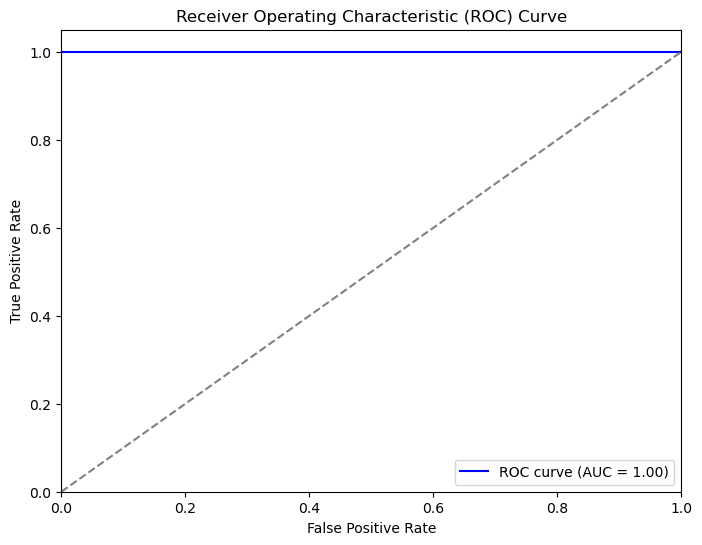

In [49]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Load the Iris dataset
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target

# For simplicity, we'll classify "Setosa" (species=0) vs "Non-Setosa" (species=1 or 2)
iris_df['species'] = iris_df['species'].apply(lambda x: 1 if x != 0 else 0)

# 1. Split the data into features (X) and target variable (y)
X = iris_df.drop('species', axis=1)  # Features
y = iris_df['species']  # Target variable (binary: 0 or 1)

# 2. Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Train Logistic Regression model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# 4. Predict probabilities on the test set (for ROC-AUC calculation)
y_pred_prob = model.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class (class=1)

# 5. Calculate the ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score: {roc_auc}")

# 6. Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc_value = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

17] Write a Python program to train Logistic Regression using a custom learning rate (C=0.5) and evaluate 
accuracy

In [50]:
# 3. Train Logistic Regression model with custom regularization strength (C=0.5)
model = LogisticRegression(C=0.5, max_iter=200, multi_class='ovr')
model.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = model.predict(X_test)

# 5. Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with C=0.5: {accuracy:.4f}")

Accuracy with C=0.5: 1.0000


18] Write a Python program to train Logistic Regression and identify important features based on model 
coefficients

In [52]:
#Get model coefficients
coefficients = model.coef_  # Coefficients for each feature and class
features = X.columns  # Feature names

# Identify important features based on coefficients
# Flatten the coefficients array for easier interpretation
coefficients_flat = coefficients.flatten()

# Create a DataFrame with feature names and corresponding coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients_flat
})

# Sort the coefficients by the absolute value (most important features will have larger magnitudes)
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df_sorted = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# Display the important features
print(coef_df_sorted[['Feature', 'Coefficient']])

             Feature  Coefficient
2  petal length (cm)     1.832256
3   petal width (cm)     0.746847
1   sepal width (cm)    -0.660638
0  sepal length (cm)     0.395453


19] Write a Python program to train Logistic Regression and evaluate its performance using Cohen’s Kappa 
Score

In [54]:
from sklearn.metrics import cohen_kappa_score

model = LogisticRegression(max_iter=200, multi_class='ovr', solver='liblinear')
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Cohen's Kappa score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa Score: {kappa_score:.4f}")

Cohen's Kappa Score: 1.0000


20] Write a Python program to train Logistic Regression and visualize the Precision-Recall Curve for binary 
classification

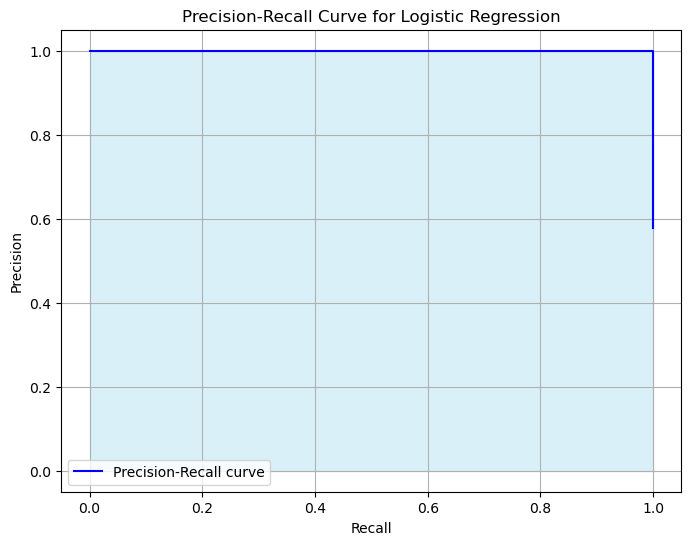

Area Under Precision-Recall Curve (AUC-PR): 1.0000


In [57]:
from sklearn.metrics import precision_recall_curve, auc

#Generate Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', label=f'Precision-Recall curve')
plt.fill_between(recall, precision, color='skyblue', alpha=0.3)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Logistic Regression')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

# Calculate and print the area under the Precision-Recall curve (AUC-PR)
pr_auc = auc(recall, precision)
print(f'Area Under Precision-Recall Curve (AUC-PR): {pr_auc:.4f}')

21] Write a Python program to train Logistic Regression with different solvers (liblinear, saga, lbfgs) and compare 
their accuracy

In [58]:
solvers = ['liblinear', 'saga', 'lbfgs']
accuracies = {}

#  Train Logistic Regression models with different solvers
for solver in solvers:
    model = LogisticRegression(solver=solver, max_iter=200, multi_class='ovr', random_state=42)
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Evaluate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracies[solver] = accuracy
    print(f"Accuracy with solver '{solver}': {accuracy:.4f}")

#  Compare results
print("\nComparison of accuracy for different solvers:")
for solver, accuracy in accuracies.items():
    print(f"Solver: {solver}, Accuracy: {accuracy:.4f}")

Accuracy with solver 'liblinear': 1.0000
Accuracy with solver 'saga': 1.0000
Accuracy with solver 'lbfgs': 1.0000

Comparison of accuracy for different solvers:
Solver: liblinear, Accuracy: 1.0000
Solver: saga, Accuracy: 1.0000
Solver: lbfgs, Accuracy: 1.0000


22] Write a Python program to train Logistic Regression and evaluate its performance using Matthews 
Correlation Coefficient (MCC)

In [60]:
from sklearn.metrics import matthews_corrcoef

# Train Logistic Regression model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)

print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

Matthews Correlation Coefficient (MCC): 1.0000


23]Write a Python program to train Logistic Regression on both raw and standardized data. Compare their 
accuracy to see the impact of feature scaling

In [61]:
 #Train Logistic Regression on raw data
model_raw = LogisticRegression(max_iter=200)
model_raw.fit(X_train, y_train)

# Make predictions on the test set using raw data
y_pred_raw = model_raw.predict(X_test)

# Calculate accuracy on raw data
accuracy_raw = accuracy_score(y_test, y_pred_raw)
print(f"Accuracy with raw data: {accuracy_raw:.4f}")

#  Standardize the features (scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression on standardized data
model_scaled = LogisticRegression(max_iter=200)
model_scaled.fit(X_train_scaled, y_train)

#  Make predictions on the test set using standardized data
y_pred_scaled = model_scaled.predict(X_test_scaled)

# Calculate accuracy on standardized data
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
print(f"Accuracy with standardized data: {accuracy_scaled:.4f}")

# Compare the results
print(f"\nComparison of accuracies:")
print(f"Accuracy with raw data: {accuracy_raw:.4f}")
print(f"Accuracy with standardized data: {accuracy_scaled:.4f}")

Accuracy with raw data: 1.0000
Accuracy with standardized data: 1.0000

Comparison of accuracies:
Accuracy with raw data: 1.0000
Accuracy with standardized data: 1.0000


24] Write a Python program to train Logistic Regression and find the optimal C (regularization strength) using 
cross-validation

In [62]:
#Define the range of C values to test
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Set up the Logistic Regression model
log_reg = LogisticRegression(max_iter=200)

# Perform cross-validation to find the optimal C using GridSearchCV
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the optimal C
optimal_C = grid_search.best_params_['C']
print(f"Optimal C (regularization strength): {optimal_C}")

# Train the Logistic Regression model with the optimal C
best_model = grid_search.best_estimator_

#  Make predictions on the test set
y_pred = best_model.predict(X_test)

#  Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with optimal C: {accuracy:.4f}")

Optimal C (regularization strength): 0.1
Accuracy with optimal C: 1.0000


25] Write a Python program to train Logistic Regression, save the trained model using joblib, and load it again to 
make predictions.

In [64]:
import joblib

# Save the trained model using joblib
joblib.dump(model, 'logistic_regression_model.pkl')

# Load the saved model
loaded_model = joblib.load('logistic_regression_model.pkl')

# Make predictions using the loaded model
y_pred = loaded_model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the model: {accuracy * 100:.2f}%")

# Predict a new sample (optional example)
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])  # Example sample from the Iris dataset
new_prediction = loaded_model.predict(new_sample)
print(f"Prediction for the new sample: {new_prediction[0]}")

Accuracy of the model: 100.00%
Prediction for the new sample: 0
